# Solving the Helmholtz Equation: Numerical Methods vs. Physics-Informed Neural Networks

This notebook solves the **2D Helmholtz (eigenvalue) equation** using two approaches:

1. **Numerical Method** — Finite Difference Method (FDM) with a sparse eigenvalue solver
2. **Neural Network** — Physics-Informed Neural Network (PINN) via PyTorch

---

## Problem Statement

### Helmholtz / Eigenvalue Equation

The **2D Helmholtz equation** is:

$$\nabla^2 u + k^2 u = f(x, y), \quad (x, y) \in \Omega = [0, 1]^2$$

**Two regimes are covered in this notebook:**

#### A. Forced Helmholtz (source problem)

Given a known $k$ and a manufactured source $f$, find $u$ satisfying:

$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + k^2\, u = f(x, y)$$

with homogeneous Dirichlet boundary conditions $u = 0$ on $\partial\Omega$.

**Manufactured solution** (used for error verification):

$$u^*(x, y) = \sin(m\pi x)\,\sin(n\pi y), \quad k^2 = (m\pi)^2 + (n\pi)^2 - k_{\text{shift}}^2$$

We choose $m = n = 1$, $k^2 = 1$ so that:

$$f(x, y) = \bigl(k^2 - (m^2 + n^2)\pi^2\bigr)\,\sin(m\pi x)\,\sin(n\pi y)$$

#### B. Eigenvalue problem

Find pairs $(\lambda_i, \phi_i)$ (eigenvalues and eigenfunctions) satisfying:

$$-\nabla^2 \phi = \lambda\, \phi, \quad \phi = 0 \text{ on } \partial\Omega$$

Analytical eigenvalues: $\lambda_{mn} = \pi^2(m^2 + n^2)$, $\quad m, n = 1, 2, \ldots$


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse import lil_matrix, eye as speye
from scipy.sparse.linalg import spsolve, eigsh
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

CMAP = "inferno"

# ── Problem parameters ────────────────────────────────────
M, N_MODE = 1, 1          # mode indices for manufactured solution
K2 = 1.0                  # Helmholtz wavenumber squared (k²)

def u_exact(X, Y, m=M, n=N_MODE):
    """Manufactured exact solution: sin(m\\pix)·sin(n\\pi y)."""
    return np.sin(m * np.pi * X) * np.sin(n * np.pi * Y)

def source_f(X, Y, m=M, n=N_MODE, k2=K2):
    """Source term f = (k² - (m²+n²)π²)·sin(m\\pix)·sin(n\\pi y)."""
    return (k2 - (m**2 + n**2) * np.pi**2) * u_exact(X, Y, m, n)

print(f"k^2 = {K2},  f coefficient = {K2 - (M**2 + N_MODE**2) * np.pi**2:.4f}")
print(f"Exact solution: sin({M}\\pi x) \\cdot sin({N_MODE}\\pi y)")

k^2 = 1.0,  f coefficient = -18.7392
Exact solution: sin(1\pi x) \cdot sin(1\pi y)


---

## Part 1 — Numerical Method: Finite Difference Method (FDM)

### 1-A. Forced Helmholtz: Solving $(\nabla^2 + k^2)u = f$

We discretize on an $N \times N$ grid. At each interior node the 5-point Laplacian stencil gives:

$$\frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h^2} + \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h^2} + k^2 u_{i,j} = f_{i,j}$$

Rearranging, this yields the sparse linear system:

$$(L + k^2 I)\, \mathbf{u} = \mathbf{f}$$

where $L$ is the standard FD Laplacian matrix. Boundary rows enforce $u = 0$.


In [20]:
def build_fdm_laplacian(N):
    """
    Assembles the sparse FD Laplacian matrix for the $[0,1]^2$ domain
    with homogeneous Dirichlet BCs.  Interior nodes only — returns
    (L_int, x_int, y_int) where L_int acts on the interior DOFs only.
    """
    h = 1.0 / (N + 1)           # N interior nodes -> $h = 1/(N+1)$
    n2 = N * N                   # total interior unknowns

    def idx(i, j):               # (i,j) in $[0,N-1]^2$
        return i * N + j

    A = lil_matrix((n2, n2))

    for i in range(N):
        for j in range(N):
            k = idx(i, j)
            A[k, k] = -4.0
            if i > 0:     A[k, idx(i-1, j)] = 1.0
            if i < N-1:   A[k, idx(i+1, j)] = 1.0
            if j > 0:     A[k, idx(i, j-1)] = 1.0
            if j < N-1:   A[k, idx(i, j+1)] = 1.0

    A = A / h**2

    xi = np.linspace(h, 1 - h, N)
    X_int, Y_int = np.meshgrid(xi, xi)   # shape (N, N), row = y, col = x

    return A.tocsr(), X_int, Y_int, h


def solve_helmholtz_fdm(N=60, k2=K2):
    """
    Solves (∇² + k²)u = f on $[0,1]^2$ with Dirichlet BCs u=0.
    Returns full $(N+2) \times (N+2)$ grid including boundary.
    """
    L, X_int, Y_int, h = build_fdm_laplacian(N)
    F_int = source_f(X_int, Y_int).ravel()

    # $(L + k^2I) u = f$
    A = L + k2 * speye(N * N, format="csr")
    u_int = spsolve(A, F_int)
    U_int = u_int.reshape(N, N)

    # Embed into full grid with zero boundary
    N_full = N + 2
    U_full = np.zeros((N_full, N_full))
    U_full[1:-1, 1:-1] = U_int

    x_full = np.linspace(0, 1, N_full)
    X_full, Y_full = np.meshgrid(x_full, x_full)
    return X_full, Y_full, U_full


N_FDM = 60
X_fdm, Y_fdm, U_fdm = solve_helmholtz_fdm(N=N_FDM, k2=K2)
U_ref = u_exact(X_fdm, Y_fdm)
fdm_error = np.abs(U_fdm - U_ref)

print(f"FDM interior grid : {N_FDM}×{N_FDM}  ({N_FDM**2} unknowns)")
print(f"Max absolute error: {fdm_error.max():.3e}")
print(f"Mean absolute error: {fdm_error.mean():.3e}")

FDM interior grid : 60×60  (3600 unknowns)
Max absolute error: 2.327e-04
Mean absolute error: 9.132e-05


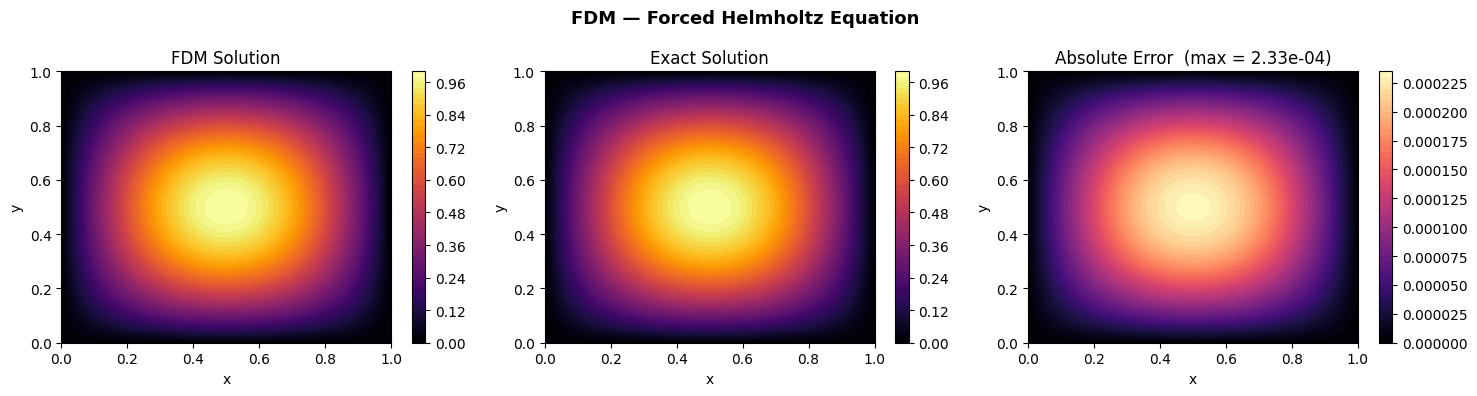

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].contourf(X_fdm, Y_fdm, U_fdm, levels=50, cmap=CMAP)
axes[0].set_title("FDM Solution")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_fdm, Y_fdm, U_ref, levels=50, cmap=CMAP)
axes[1].set_title("Exact Solution")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X_fdm, Y_fdm, fdm_error, levels=50, cmap="magma")
axes[2].set_title(f"Absolute Error  (max = {fdm_error.max():.2e})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("FDM — Forced Helmholtz Equation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1-B. Eigenvalue Problem: $-\nabla^2 \phi = \lambda\, \phi$

We solve the generalized algebraic eigenvalue problem $-L\,\mathbf{v} = \lambda\,\mathbf{v}$ using `scipy.sparse.linalg.eigsh` (ARPACK Lanczos method).

Analytical eigenvalues for the unit square: $\lambda_{mn} = \pi^2(m^2 + n^2)$.

| $(m,n)$ | $\lambda_{mn}$ |
|---------|----------------|
| $(1,1)$ | $2\pi^2 \approx 19.739$ |
| $(1,2)$ or $(2,1)$ | $5\pi^2 \approx 49.348$ |
| $(2,2)$ | $8\pi^2 \approx 78.957$ |
| $(1,3)$ or $(3,1)$ | $10\pi^2 \approx 98.696$ |


In [22]:
N_EIG = 60                    # interior grid size for eigenvalue solve
N_EIG_MODES = 6               # how many modes to compute

L_eig, X_int_eig, Y_int_eig, h_eig = build_fdm_laplacian(N_EIG)

# Solve  $-L v = \lambda v$  ->  smallest algebraic eigenvalues of $-L$
eigenvalues, eigenvectors = eigsh(-L_eig, k=N_EIG_MODES, which="SM")

# Sort ascending
order = np.argsort(eigenvalues)
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Embed eigenvectors into full grid
N_full_eig = N_EIG + 2
x_full_eig = np.linspace(0, 1, N_full_eig)
X_full_eig, Y_full_eig = np.meshgrid(x_full_eig, x_full_eig)

def embed(v_flat, N, N_full):
    U = np.zeros((N_full, N_full))
    U[1:-1, 1:-1] = v_flat.reshape(N, N)
    return U

# Print comparison table
print(f"{'Mode (m,n)':<14} {'λ exact':>12} {'λ FDM':>12} {'Rel. error':>12}")
print("-" * 54)
analytic_modes = [(1,1),(1,2),(2,1),(2,2),(1,3),(3,1)]
for i, (m, n) in enumerate(analytic_modes[:N_EIG_MODES]):
    lam_exact = np.pi**2 * (m**2 + n**2)
    lam_fdm   = eigenvalues[i]
    rel_err   = abs(lam_fdm - lam_exact) / lam_exact
    print(f"({m},{n}){'':9} {lam_exact:>12.4f} {lam_fdm:>12.4f} {rel_err:>12.2e}")

Mode (m,n)          λ exact        λ FDM   Rel. error
------------------------------------------------------
(1,1)               19.7392      19.7348     2.21e-04
(1,2)               49.3480      49.3109     7.51e-04
(2,1)               49.3480      49.3109     7.51e-04
(2,2)               78.9568      78.8871     8.84e-04
(1,3)               98.6960      98.5173     1.81e-03
(3,1)               98.6960      98.5173     1.81e-03


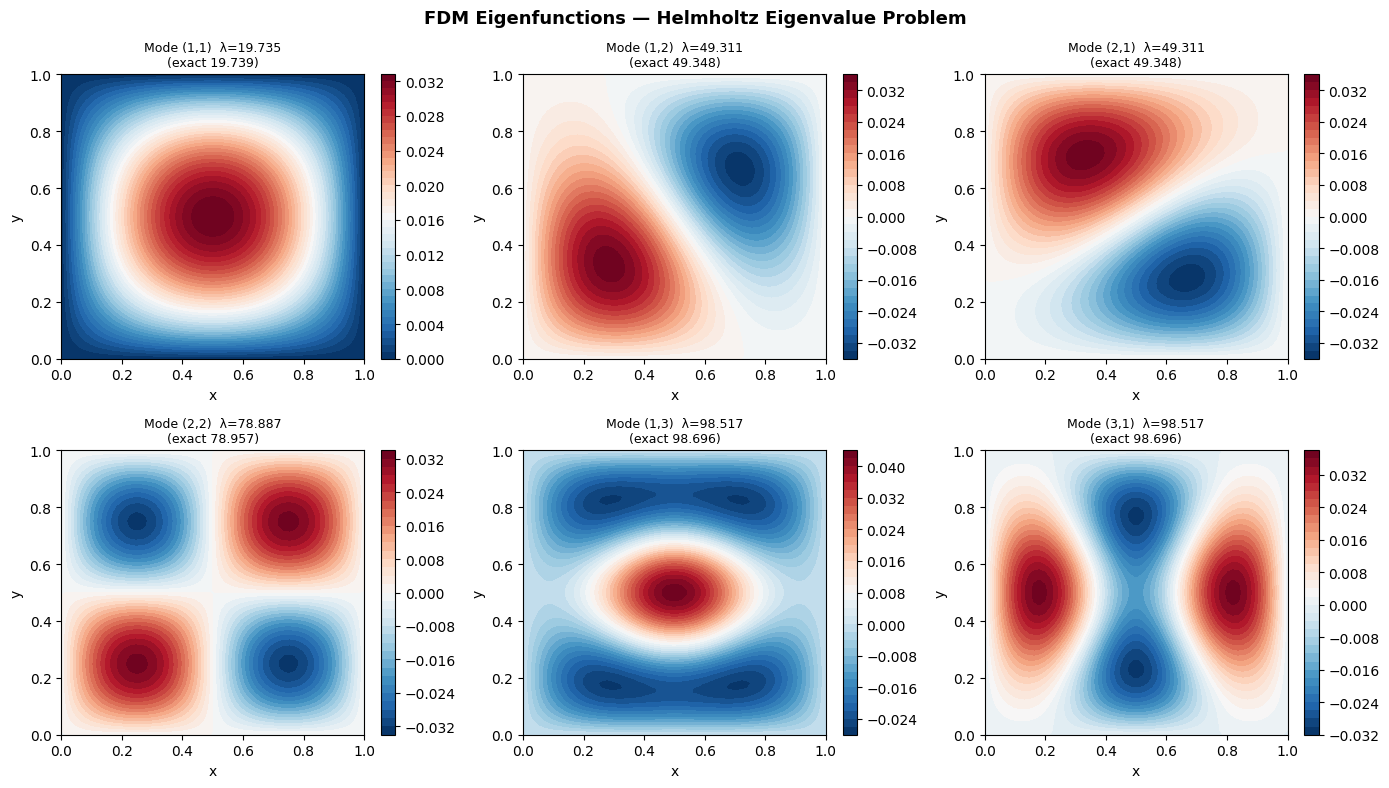

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i in range(N_EIG_MODES):
    phi = embed(eigenvectors[:, i], N_EIG, N_full_eig)
    # Fix sign so interior maximum is positive
    if phi[1:-1, 1:-1].max() < -phi[1:-1, 1:-1].min():
        phi = -phi
    m, n = analytic_modes[i]
    lam_exact = np.pi**2 * (m**2 + n**2)
    cf = axes[i].contourf(X_full_eig, Y_full_eig, phi, levels=40, cmap="RdBu_r")
    axes[i].set_title(
        f"Mode ({m},{n})  λ={eigenvalues[i]:.3f}\n(exact {lam_exact:.3f})",
        fontsize=9
    )
    axes[i].set_xlabel("x"); axes[i].set_ylabel("y")
    plt.colorbar(cf, ax=axes[i], fraction=0.046)

plt.suptitle("FDM Eigenfunctions — Helmholtz Eigenvalue Problem", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Part 2 — Neural Network: Physics-Informed Neural Network (PINN)

### 2-A. Forced Helmholtz PINN

We train a network $\hat{u}_\theta(x,y)$ to minimise:

$$\mathcal{L} = \underbrace{\mathcal{L}_{BC}}_{\text{boundary}} + \underbrace{\mathcal{L}_{PDE}}_{\text{physics}}$$

$$\mathcal{L}_{PDE} = \frac{1}{N_f}\sum_k \left(\hat{u}_{xx} + \hat{u}_{yy} + k^2\hat{u} - f\right)^2$$

All derivatives are obtained via `torch.autograd` — no finite-difference stencil required.

### 2-B. Eigenfunction PINN (Ritz method)

To recover the fundamental eigenmode we train a network $\hat{\phi}_\theta(x,y)$ to minimise the **Rayleigh quotient**:

$$R[\hat{\phi}] = \frac{\displaystyle\int_\Omega |\nabla\hat{\phi}|^2\,d\Omega}{\displaystyle\int_\Omega \hat{\phi}^2\,d\Omega}$$

The minimum of $R$ over all admissible functions is $\lambda_1$ by the Courant–Fischer theorem.  
Boundary conditions are enforced via a **hard constraint**: $\hat{\phi}(x,y) = x(1-x)\,y(1-y)\cdot N_\theta(x,y)$.


In [25]:
# ------------------------------------------------------------------------
# Shared Architecture
# ------------------------------------------------------------------------
class MLP(nn.Module):
    """Fully-connected network with Tanh activations: $(x,y)$ -> scalar."""
    def __init__(self, hidden_layers=4, hidden_dim=64):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))


def grad1(u, v):
    """$\\frac{\\partial u}{\\partial v}$ via autograd, keeping graph for higher-order derivatives."""
    return torch.autograd.grad(
        u, v,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]


# ---- Collocation / boundary points ------------------------------------------------
N_BC   = 200    # points per boundary edge
N_INT  = 5000   # interior physics points

def boundary_tensors(n):
    """Returns $(x_bc, y_bc)$ along all four edges (zero Dirichlet)."""
    t = torch.rand(n, 1)
    xb = torch.cat([t, t, torch.zeros(n,1), torch.ones(n,1)])
    yb = torch.cat([torch.zeros(n,1), torch.ones(n,1), t, t])
    return xb, yb

x_bc_p, y_bc_p = boundary_tensors(N_BC)
u_bc_zeros = torch.zeros(x_bc_p.shape[0], 1)

x_int_p = torch.rand(N_INT, 1, requires_grad=True)
y_int_p = torch.rand(N_INT, 1, requires_grad=True)

# Source values at interior points
f_int = torch.tensor(
    source_f(x_int_p.detach().numpy(), y_int_p.detach().numpy()),
    dtype=torch.float32
)

print(f"PINN boundary points : {x_bc_p.shape[0]}")
print(f"PINN interior points : {x_int_p.shape[0]}")

PINN boundary points : 800
PINN interior points : 5000


In [26]:
mse = nn.MSELoss()

def helmholtz_loss(model, x_int, y_int, f_int, x_bc, y_bc, u_bc, k2=K2):
    # Boundary loss
    loss_bc = mse(model(x_bc, y_bc), u_bc)

    # PDE residual: u_xx + u_yy + k²u = f
    u = model(x_int, y_int)
    u_x  = grad1(u, x_int)
    u_y  = grad1(u, y_int)
    u_xx = grad1(u_x, x_int)
    u_yy = grad1(u_y, y_int)
    residual = u_xx + u_yy + k2 * u - f_int
    loss_pde = mse(residual, torch.zeros_like(residual))

    return loss_bc + loss_pde, loss_bc, loss_pde


# ---- Phase 1: Adam -------------------------------------------------------------------------------
model_helm = MLP(hidden_layers=4, hidden_dim=64)
opt_adam = optim.Adam(model_helm.parameters(), lr=1e-3)
ADAM_EP = 3000
history_helm = []

for ep in range(1, ADAM_EP + 1):
    opt_adam.zero_grad()
    loss, l_bc, l_pde = helmholtz_loss(
        model_helm, x_int_p, y_int_p, f_int, x_bc_p, y_bc_p, u_bc_zeros
    )
    loss.backward()
    opt_adam.step()
    history_helm.append(loss.item())
    if ep % 500 == 0:
        print(f"[Adam] Ep {ep:5d} | Loss {loss.item():.5f} | BC {l_bc.item():.5f} | PDE {l_pde.item():.5f}")

# ---- Phase 2: L-BFGS ----------------------------------------------------------------------------
opt_lbfgs = optim.LBFGS(
    model_helm.parameters(),
    max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-12,
    history_size=50, line_search_fn="strong_wolfe"
)

def closure_helm():
    opt_lbfgs.zero_grad()
    loss, _, _ = helmholtz_loss(
        model_helm, x_int_p, y_int_p, f_int, x_bc_p, y_bc_p, u_bc_zeros
    )
    loss.backward()
    history_helm.append(loss.item())
    return loss

opt_lbfgs.step(closure_helm)
final, _, _ = helmholtz_loss(model_helm, x_int_p, y_int_p, f_int, x_bc_p, y_bc_p, u_bc_zeros)
print(f"\nL-BFGS done.  Final loss: {final.item():.6f}")

[Adam] Ep   500 | Loss 0.04369 | BC 0.01659 | PDE 0.02710
[Adam] Ep  1000 | Loss 0.01632 | BC 0.01256 | PDE 0.00376
[Adam] Ep  1500 | Loss 0.01192 | BC 0.01038 | PDE 0.00154
[Adam] Ep  2000 | Loss 0.00995 | BC 0.00908 | PDE 0.00086
[Adam] Ep  2500 | Loss 0.00860 | BC 0.00792 | PDE 0.00068
[Adam] Ep  3000 | Loss 0.00743 | BC 0.00682 | PDE 0.00060

L-BFGS done.  Final loss: 0.000050


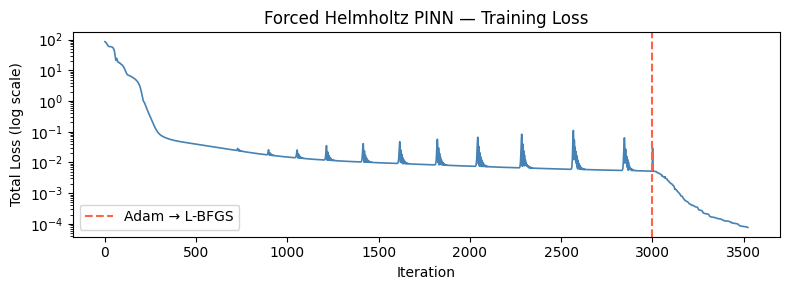

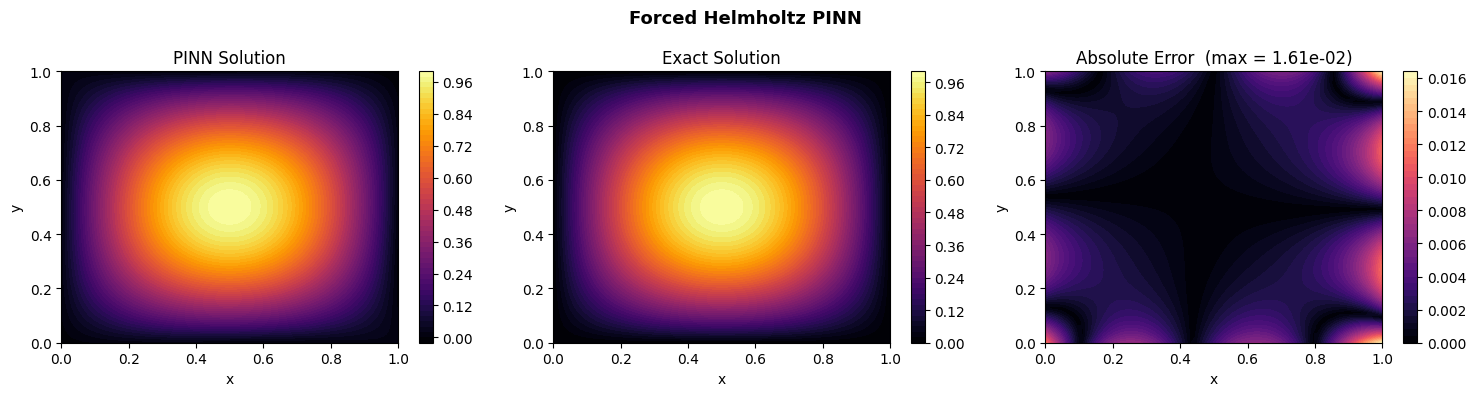

PINN — Max error: 1.61e-02  |  Mean error: 2.16e-03


In [ ]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(history_helm, color="steelblue", lw=1.2)
ax.axvline(x=ADAM_EP, color="tomato", ls="--", label="Adam → L-BFGS")
ax.set_xlabel("Iteration"); ax.set_ylabel("Total Loss (log scale)")
ax.set_title("Forced Helmholtz PINN — Training Loss")
ax.legend(); plt.tight_layout(); plt.show()

# Evaluate on dense grid
model_helm.eval()
N_ev = 64
xv = np.linspace(0, 1, N_ev); yv = np.linspace(0, 1, N_ev)
Xv, Yv = np.meshgrid(xv, yv)
xt = torch.tensor(Xv.ravel(), dtype=torch.float32).unsqueeze(1)
yt = torch.tensor(Yv.ravel(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    U_pinn = model_helm(xt, yt).numpy().reshape(N_ev, N_ev)

U_ref_pinn = u_exact(Xv, Yv)
pinn_error = np.abs(U_pinn - U_ref_pinn)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].contourf(Xv, Yv, U_pinn, levels=50, cmap=CMAP)
axes[0].set_title("PINN Solution"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(Xv, Yv, U_ref_pinn, levels=50, cmap=CMAP)
axes[1].set_title("Exact Solution"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(Xv, Yv, pinn_error, levels=50, cmap="magma")
axes[2].set_title(f"Absolute Error  (max = {pinn_error.max():.2e})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Forced Helmholtz PINN", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"PINN — Max error: {pinn_error.max():.2e}  |  Mean error: {pinn_error.mean():.2e}")

### 2-B. Eigenfunction PINN via Rayleigh Quotient Minimisation

We parameterise the trial function with a **hard boundary constraint**:

$$\hat{\phi}(x, y) = x(1-x)\,y(1-y)\cdot N_\theta(x,y)$$

This guarantees $\hat{\phi} = 0$ on $\partial\Omega$ exactly, so we only need to minimise the Rayleigh quotient:

$$R[\hat{\phi}] = \frac{\int_\Omega |\nabla\hat{\phi}|^2\,d\Omega}{\int_\Omega \hat{\phi}^2\,d\Omega}$$

The integrals are approximated by Monte Carlo sampling over the unit square.  
$R$ converges to $\lambda_1 = 2\pi^2 \approx 19.739$ from above.


In [ ]:
N_RITZ = 4000   # Monte-Carlo quadrature points

class EigenPINN(nn.Module):
    """
    Hard-constraint PINN for the eigenvalue problem.
    $\hat{\varphi}(x,y) = x(1-x) \cdot y(1-y) \cdot N(x,y)$   <- automatically zero on ∂Ω
    """
    def __init__(self, hidden_layers=4, hidden_dim=64):
        super().__init__()
        layers = [nn.Linear(2, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, y):
        mask = x * (1 - x) * y * (1 - y)   # hard BC factor
        return mask * self.net(torch.cat([x, y], dim=1))


def rayleigh_loss(model, x, y):
    """Returns the Rayleigh quotient $R = \int\|\Nabla\varphi\|^2 / \int\varphi^2$  (Monte Carlo)."""
    phi = model(x, y)
    phi_x = grad1(phi, x)
    phi_y = grad1(phi, y)
    numerator   = (phi_x**2 + phi_y**2).mean()
    denominator = (phi**2).mean() + 1e-10     # \varepsilon prevents division by zero
    return numerator / denominator


# Sample interior points (re-sampled each call keeps training robust)
x_ritz = torch.rand(N_RITZ, 1, requires_grad=True)
y_ritz = torch.rand(N_RITZ, 1, requires_grad=True)

model_eig = EigenPINN(hidden_layers=4, hidden_dim=64)
opt_eig   = optim.Adam(model_eig.parameters(), lr=5e-4)

EIG_EP = 5000
history_eig = []
lambda_history = []

for ep in range(1, EIG_EP + 1):
    opt_eig.zero_grad()
    Rq = rayleigh_loss(model_eig, x_ritz, y_ritz)
    Rq.backward()
    opt_eig.step()
    history_eig.append(Rq.item())
    lambda_history.append(Rq.item())

    if ep % 1000 == 0:
        print(f"[Adam] Ep {ep:5d} | R = {Rq.item():.5f}  (target λ₁ = {2*np.pi**2:.5f})")

print(f"\nFinal Rayleigh quotient  : {Rq.item():.5f}")
print(f"Analytical λ₁ = 2π²     : {2*np.pi**2:.5f}")
print(f"Relative error           : {abs(Rq.item() - 2*np.pi**2)/(2*np.pi**2):.2e}")

[Adam] Ep  1000 | R = 19.91364  (target λ₁ = 19.73921)
[Adam] Ep  2000 | R = 19.91233  (target λ₁ = 19.73921)
[Adam] Ep  3000 | R = 19.91138  (target λ₁ = 19.73921)
[Adam] Ep  4000 | R = 19.96210  (target λ₁ = 19.73921)
[Adam] Ep  5000 | R = 19.90964  (target λ₁ = 19.73921)

Final Rayleigh quotient  : 19.90964
Analytical λ₁ = 2π²     : 19.73921
Relative error           : 8.63e-03


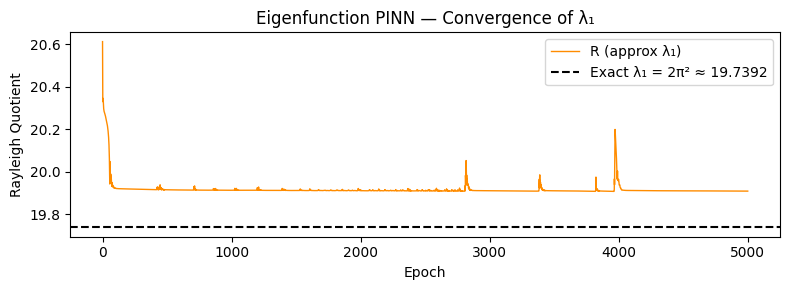

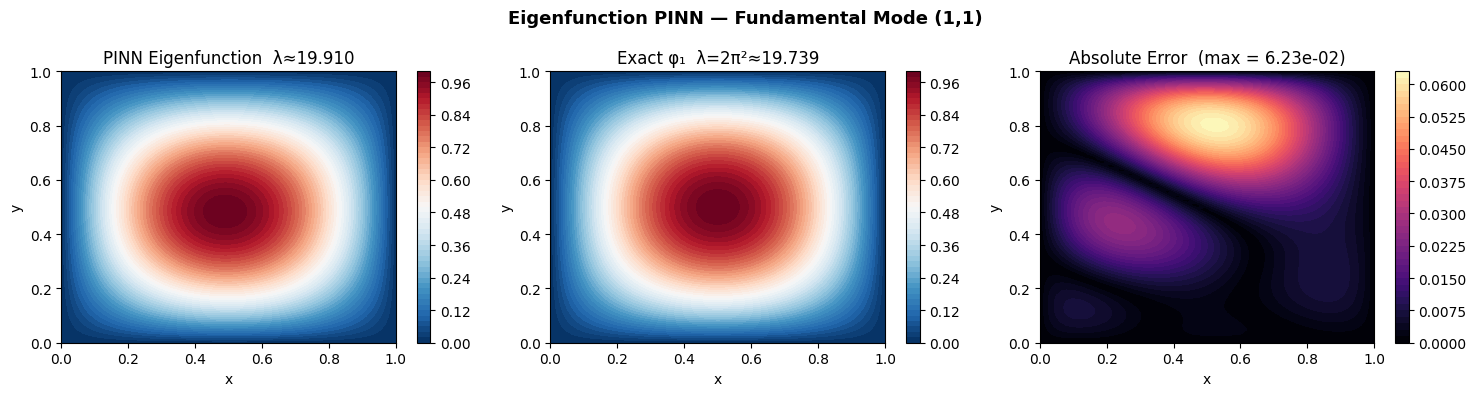

In [ ]:
# Convergence of Rayleigh quotient
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(lambda_history, color="darkorange", lw=1.0, label="R (approx $\lambda_1$)")
ax.axhline(y=2*np.pi**2, color="black", ls="--", lw=1.5, label=f"Exact $\lambda_1 = 2\pi^2 \approx$ {2*np.pi**2:.4f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Rayleigh Quotient")
ax.set_title("Eigenfunction PINN — Convergence of $\lambda_1$")
ax.legend(); plt.tight_layout(); plt.show()

# Evaluate eigenfunction on dense grid
model_eig.eval()
xev = torch.tensor(Xv.ravel(), dtype=torch.float32).unsqueeze(1)
yev = torch.tensor(Yv.ravel(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    phi_pinn = model_eig(xev, yev).numpy().reshape(N_ev, N_ev)

# Normalise so peak is positive 1
phi_pinn /= np.max(np.abs(phi_pinn))
if phi_pinn[N_ev//2, N_ev//2] < 0:
    phi_pinn = -phi_pinn

# Reference eigenfunction  $\varphi_1(x,y) = sin(\pi x) \cdot sin(\pi y)$  (normalised to peak 1)
phi_ref = np.sin(np.pi * Xv) * np.sin(np.pi * Yv)
phi_ref /= phi_ref.max()

eig_error = np.abs(phi_pinn - phi_ref)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cf0 = axes[0].contourf(Xv, Yv, phi_pinn, levels=50, cmap="RdBu_r")
axes[0].set_title(f"PINN Eigenfunction  $\lambda \approx {lambda_history[-1]:.3f}$")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(cf0, ax=axes[0])

cf1 = axes[1].contourf(Xv, Yv, phi_ref, levels=50, cmap="RdBu_r")
axes[1].set_title(f"Exact $\varphi_1$  $\lambda=2\pi^2 \approx {2*np.pi**2:.3f}$")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(cf1, ax=axes[1])

cf2 = axes[2].contourf(Xv, Yv, eig_error, levels=50, cmap="magma")
axes[2].set_title(f"Absolute Error  (max = {eig_error.max():.2e})")
axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
plt.colorbar(cf2, ax=axes[2])

plt.suptitle("Eigenfunction PINN — Fundamental Mode (1,1)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---

## Part 3 — Side-by-Side Comparison

### 3-A. Forced Helmholtz: FDM vs. PINN vs. Exact


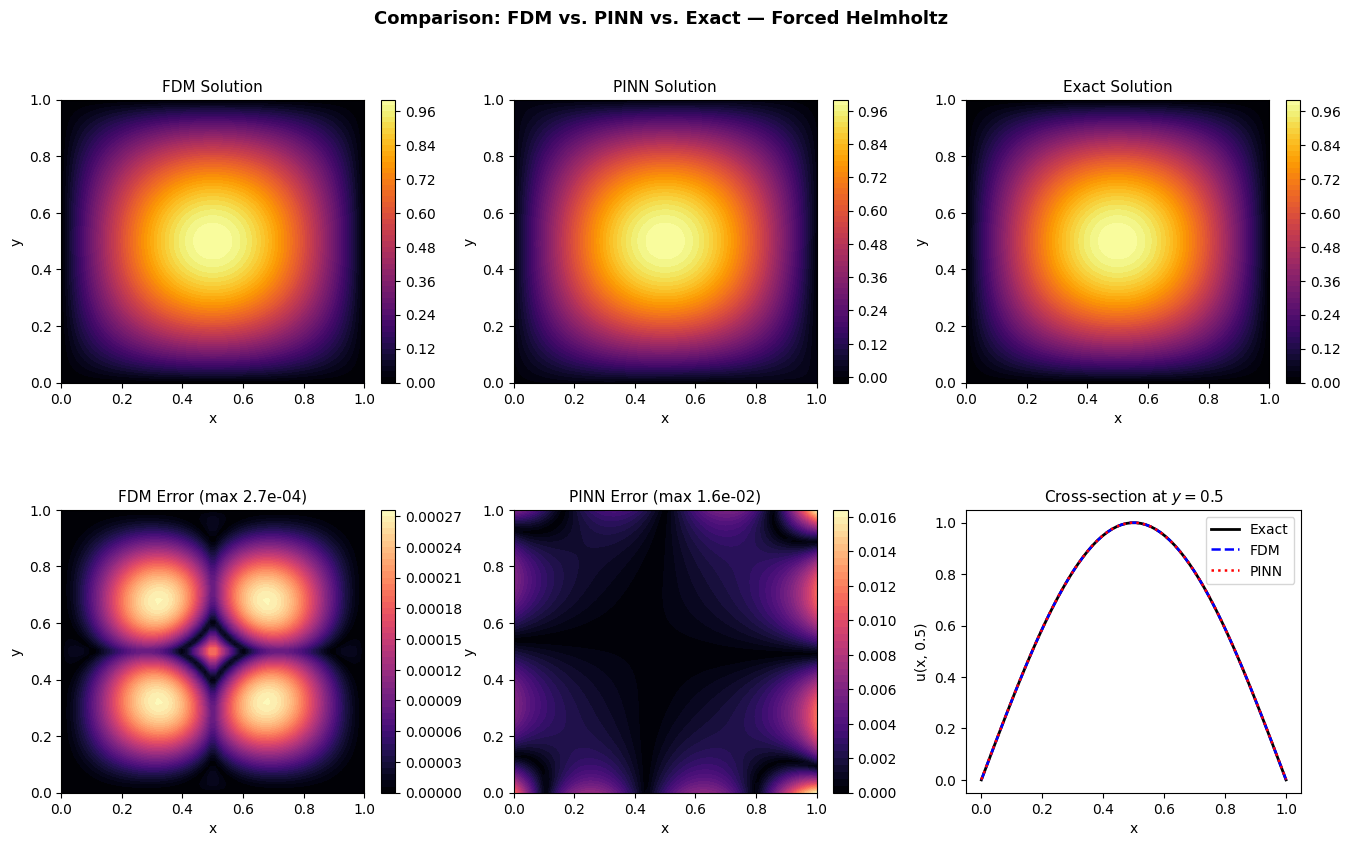

In [ ]:
# Interpolate FDM onto the evaluation grid (both grids are uniform $[0,1]$)
from scipy.interpolate import RegularGridInterpolator

x_fdm_1d = X_fdm[0, :]
y_fdm_1d = Y_fdm[:, 0]
interp_fdm = RegularGridInterpolator(
    (y_fdm_1d, x_fdm_1d), U_fdm, method="linear", bounds_error=False, fill_value=0.0
)
pts = np.stack([Yv.ravel(), Xv.ravel()], axis=1)
U_fdm_ev = interp_fdm(pts).reshape(N_ev, N_ev)
fdm_err_ev = np.abs(U_fdm_ev - U_ref_pinn)

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Row 0 — solutions
for col, (title, sol) in enumerate(
    [("FDM Solution", U_fdm_ev), ("PINN Solution", U_pinn), ("Exact Solution", U_ref_pinn)]
):
    ax = fig.add_subplot(gs[0, col])
    cf = ax.contourf(Xv, Yv, sol, levels=50, cmap=CMAP)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.colorbar(cf, ax=ax, fraction=0.046)

# Row 1 — errors + cross-section
ax_e1 = fig.add_subplot(gs[1, 0])
ax_e2 = fig.add_subplot(gs[1, 1])
ax_cs = fig.add_subplot(gs[1, 2])

cf1 = ax_e1.contourf(Xv, Yv, fdm_err_ev,  levels=50, cmap="magma")
ax_e1.set_title(f"FDM Error (max {fdm_err_ev.max():.1e})", fontsize=11)
ax_e1.set_xlabel("x"); ax_e1.set_ylabel("y")
plt.colorbar(cf1, ax=ax_e1, fraction=0.046)

cf2 = ax_e2.contourf(Xv, Yv, pinn_error, levels=50, cmap="magma")
ax_e2.set_title(f"PINN Error (max {pinn_error.max():.1e})", fontsize=11)
ax_e2.set_xlabel("x"); ax_e2.set_ylabel("y")
plt.colorbar(cf2, ax=ax_e2, fraction=0.046)

# Cross-section $y = 0.5$
y_mid = 0.5
row_ev = N_ev // 2
x_cs  = Xv[row_ev, :]
ax_cs.plot(x_cs, U_ref_pinn[row_ev, :], "k-",  lw=2,   label="Exact")
ax_cs.plot(x_cs, U_fdm_ev[row_ev, :],  "b--",  lw=1.8, label="FDM")
ax_cs.plot(x_cs, U_pinn[row_ev, :],    "r:",   lw=1.8, label="PINN")
ax_cs.set_title("Cross-section at $y = 0.5$", fontsize=11)
ax_cs.set_xlabel("x"); ax_cs.set_ylabel("u(x, 0.5)")
ax_cs.legend()

fig.suptitle("Comparison: FDM vs. PINN vs. Exact — Forced Helmholtz", fontsize=13, fontweight="bold")
plt.show()

### 3-B. Eigenvalue Problem: FDM vs. PINN


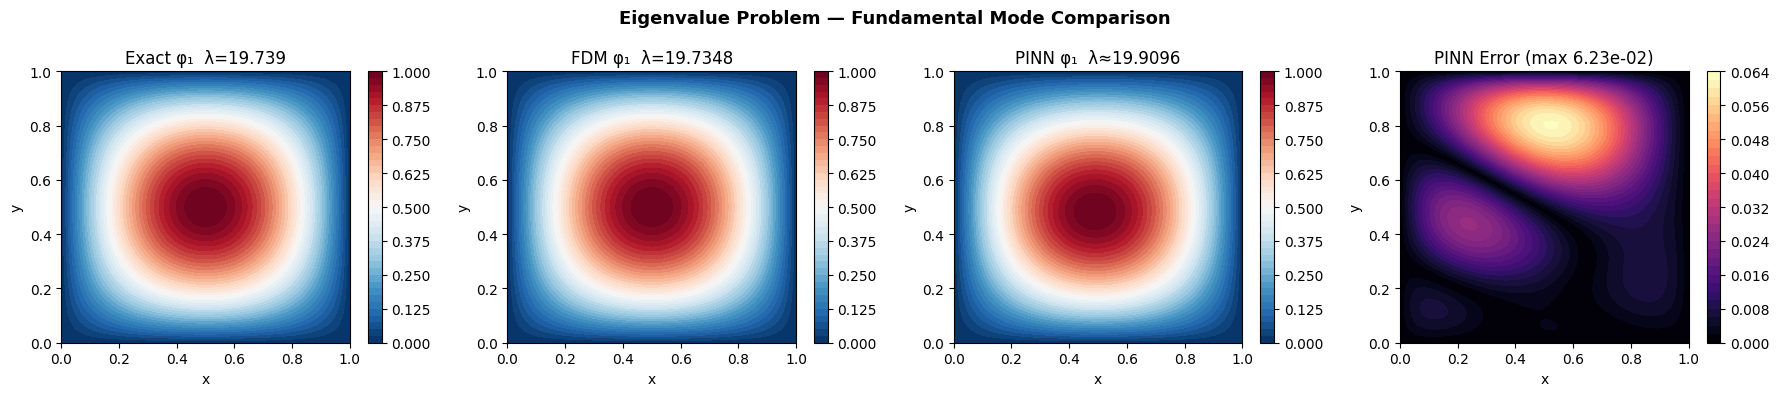

                               λ₁   Rel. error
------------------------------------------------------------
Exact                   19.739209            —
FDM                     19.734846     2.21e-04
PINN (Rayleigh)         19.909636     8.63e-03


In [ ]:
# Fundamental eigenfunction from FDM (mode index 0)
phi_fdm_full = embed(eigenvectors[:, 0], N_EIG, N_full_eig)
if phi_fdm_full[N_full_eig//2, N_full_eig//2] < 0:
    phi_fdm_full = -phi_fdm_full
phi_fdm_full /= np.max(np.abs(phi_fdm_full))

# Interpolate FDM eigenfunction onto evaluation grid
interp_eig = RegularGridInterpolator(
    (x_full_eig, x_full_eig), phi_fdm_full, method="linear",
    bounds_error=False, fill_value=0.0
)
phi_fdm_ev = interp_eig(np.stack([Yv.ravel(), Xv.ravel()], axis=1)).reshape(N_ev, N_ev)
eig_err_fdm  = np.abs(phi_fdm_ev  - phi_ref)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

cf0 = axes[0].contourf(Xv, Yv, phi_ref,     levels=40, cmap="RdBu_r")
axes[0].set_title(f"Exact φ₁  λ={2*np.pi**2:.3f}"); plt.colorbar(cf0, ax=axes[0])

cf1 = axes[1].contourf(X_full_eig, Y_full_eig, phi_fdm_full, levels=40, cmap="RdBu_r")
axes[1].set_title(f"FDM φ₁  λ={eigenvalues[0]:.4f}"); plt.colorbar(cf1, ax=axes[1])

cf2 = axes[2].contourf(Xv, Yv, phi_pinn,    levels=40, cmap="RdBu_r")
axes[2].set_title(f"PINN φ₁  λ≈{lambda_history[-1]:.4f}"); plt.colorbar(cf2, ax=axes[2])

errors = np.stack([eig_err_fdm, eig_error])
vmax_e = errors.max()
cf3 = axes[3].contourf(Xv, Yv, eig_error, levels=40, cmap="magma", vmin=0, vmax=vmax_e)
axes[3].set_title(f"PINN Error (max {eig_error.max():.2e})"); plt.colorbar(cf3, ax=axes[3])

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.suptitle("Eigenvalue Problem — Fundamental Mode Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Eigenvalue summary
print("=" * 60)
print(f"{'':20} {'λ₁':>12} {'Rel. error':>12}")
print("-" * 60)
print(f"{'Exact':20} {2*np.pi**2:>12.6f} {'—':>12}")
print(f"{'FDM':20} {eigenvalues[0]:>12.6f} {abs(eigenvalues[0]-2*np.pi**2)/(2*np.pi**2):>12.2e}")
print(f"{'PINN (Rayleigh)':20} {lambda_history[-1]:>12.6f} {abs(lambda_history[-1]-2*np.pi**2)/(2*np.pi**2):>12.2e}")
print("=" * 60)

---

## Summary

### Forced Helmholtz $(\nabla^2 + k^2)u = f$

| Aspect | FDM | PINN |
|--------|-----|------|
| **Core operation** | Solve sparse system $(L + k^2I)\mathbf{u} = \mathbf{f}$ | Minimise $\mathcal{L}_{BC} + \mathcal{L}_{PDE}$ |
| **Derivatives** | Finite-difference stencil | `torch.autograd` |
| **Accuracy** | $\mathcal{O}(h^2)$, typically $10^{-4}$–$10^{-5}$ | Typically $10^{-3}$–$10^{-4}$ |
| **Speed** | Very fast — one sparse solve | Slower — thousands of back-prop steps |
| **Near-resonance** ($k^2 \approx \lambda_{mn}$) | Matrix becomes ill-conditioned | Loss landscape remains smooth |

### Eigenvalue Problem $-\nabla^2\phi = \lambda\phi$

| Aspect | FDM (ARPACK Lanczos) | PINN (Rayleigh minimisation) |
|--------|----------------------|------------------------------|
| **Core operation** | Sparse algebraic eigensolver | Minimise Rayleigh quotient $R[\hat{\phi}]$ |
| **Multiple modes** | All $k$ modes in one call | Each mode requires a separate training run |
| **Boundary conditions** | Enforced via matrix rows | Hard constraint: $\hat{\phi} = x(1-x)y(1-y)\cdot N$ |
| **Accuracy** | $\mathcal{O}(h^2)$ for each eigenvalue | Variational upper bound; depends on training |
| **Adaptability** | Mesh required | Meshfree; handles complex geometries naturally |

**Remark:** FDM is the preferred tool for simple geometries where multiple eigenvalues are needed quickly and accurately. PINNs shine in irregular domains, parametric families of problems, and settings where a differentiable model of the solution is needed downstream.
